# calibrate_visualize.ipynb — 校准效果可视化

本 Notebook 负责：
1. 加载模型 & 校准参数
2. 构建完整期权链用于曲面可视化
3. **曲面 1**: τ × K → 期权价格（DDN vs 真实，光滑曲面）
4. **曲面 2**: τ × log(K/S₀) → 隐含波动率（DDN vs 真实，QuantLib BS 反推 IV）
5. 固定 τ 切片 IV Smile 对比（2D）

In [1]:
## Cell 1: 导入依赖 & 加载模型

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from datetime import datetime
from scipy.interpolate import interp1d, griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import QuantLib as ql

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from modules.model       import HestonDDN
from modules.calibration import HestonCalibrator
from modules.pricing     import calculate_heston_price

# ── 加载模型 ──
MODEL_PATH = PROJECT_ROOT / "models" / "heston_ddn_weights.pth"
FALLBACK_MODEL = Path("/Users/liaojiansong/calibration/heston_ddn_weights.pth")

device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)

ckpt_path = MODEL_PATH if MODEL_PATH.exists() else FALLBACK_MODEL
ckpt  = torch.load(ckpt_path, map_location=device)
model = HestonDDN(
    input_dim        = ckpt.get('input_dim', 9),
    heston_param_dim = ckpt.get('heston_dim', 5),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.is_fitted = ckpt.get('is_fitted', True)
model.eval()
print(f"✅ 模型加载完成，设备: {device}")

✅ 模型加载完成，设备: mps


In [2]:
## Cell 2: 校准参数 & 数据准备（清洗逻辑与 02_calibrate 完全一致）

DATA_DIR = Path.cwd() / "data"

# ── 筛选参数（与 02_calibrate 保持一致） ──
DTE_LO, DTE_HI       = 40, 300
LOG_KS_LO, LOG_KS_HI = -0.15, 0.2

def interest_rate(date: str, tau: float) -> float:
    maturities = np.array([1/12, 2/12, 3/12, 6/12, 1.0])
    data = pd.read_csv(ROOT / "data" / "par-yield-curve-rates-2020-2023.csv")
    ir_row = data[data['date'] == date]
    market_rates = ir_row[['1 mo', '2 mo', '3 mo', '6 mo', '1 yr']].values.flatten() / 100.0
    continuous_rates = np.log(1 + market_rates * maturities) / maturities
    yield_curve = interp1d(maturities, continuous_rates, kind='cubic', fill_value='extrapolate')
    return float(yield_curve(tau))

def load_and_clean_spy(csv_path, label, n_take=200):
    """
    清洗 SPY 期权 CSV（与 02_calibrate 完全一致）。
    输出列: r, tau, S0, K, P_mkt, log_K_S0
    仅保留 Call 期权且 C_VOLUME > 0 的行。
    n_take: 从中间截取的条数（默认100）。传 None 则返回全量。
    """
    dt_obj = datetime.strptime(label, "%Y-%m-%d")
    date = dt_obj.strftime("%m/%d/%Y")

    maturities = np.array([1/12, 2/12, 3/12, 6/12, 1.0])
    yield_data = pd.read_csv(ROOT / "data" / "par-yield-curve-rates-2020-2023.csv")
    ir_row = yield_data[yield_data['date'] == date]
    if ir_row.empty:
        raise ValueError(f"未找到日期为 {date} 的数据")
    market_rates = ir_row[['1 mo', '2 mo', '3 mo', '6 mo', '1 yr']].values.flatten() / 100.0
    continuous_rates = np.log(1 + market_rates * maturities) / maturities
    yield_curve = interp1d(maturities, continuous_rates, kind='cubic', fill_value='extrapolate')

    raw = pd.read_csv(csv_path)
    raw.columns = [c.strip().strip('[]') for c in raw.columns]
    for col in ['UNDERLYING_LAST', 'DTE', 'STRIKE', 'C_LAST', 'C_BID', 'C_ASK']:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    # ★ C_VOLUME: CSV 中可能为 str/空值，需先转数值
    raw['C_VOLUME'] = pd.to_numeric(raw['C_VOLUME'], errors='coerce')

    df = raw.dropna(subset=['UNDERLYING_LAST', 'DTE', 'STRIKE', 'C_LAST']).copy()
    df = df[df['C_LAST'] > 0.01].copy()
    df = df[df['UNDERLYING_LAST'] > 0].copy()
    df = df[df['C_VOLUME'].fillna(0) > 0].copy()   # ★ 确保有交易量
    df = df[(df['DTE'] >= DTE_LO) & (df['DTE'] <= DTE_HI)].copy()

    df['S0']       = df['UNDERLYING_LAST']
    df['K']        = df['STRIKE']
    df['P_mkt']    = (df['C_BID'] + df['C_ASK']) * 0.5
    df['tau']      = df['DTE'] / 365.0
    df['r']        = df['tau'].apply(lambda t: interest_rate(date, t))
    df['log_K_S0'] = np.log(df['K'] / df['S0'])

    df = df[(df['log_K_S0'] >= LOG_KS_LO) & (df['log_K_S0'] <= LOG_KS_HI)].copy()

    out = df[['r', 'tau', 'S0', 'K', 'P_mkt', 'log_K_S0']].reset_index(drop=True)

    # ── 自适应中间截取（与 02_calibrate 一致） ──
    if n_take is not None:
        n_actual = min(n_take, len(out))
        mid   = len(out) // 2
        start = max(0, mid - n_actual // 2)
        out   = out.iloc[start : start + n_actual].reset_index(drop=True)

    print(f"[{label}] 清洗完成: {len(out)} 条有效 Call 期权")
    if len(out) == 0:
        raise ValueError(f"[{label}] 清洗后无有效数据，请检查筛选条件")
    print(f"  S0 = {out['S0'].iloc[0]:.2f},  DTE ∈ [{out['tau'].min()*365:.0f}, {out['tau'].max()*365:.0f}] 天")
    print(f"  K  ∈ [{out['K'].min():.1f}, {out['K'].max():.1f}]")
    print(f"  log(K/S0) ∈ [{out['log_K_S0'].min():.4f}, {out['log_K_S0'].max():.4f}]")
    print(f"  P_mkt ∈ [{out['P_mkt'].min():.2f}, {out['P_mkt'].max():.2f}]")
    return out

def ddn_price_batch(theta_np, df):
    """DDN 批量定价（9维输入: 5 Heston + r, tau, S0, log_K_S0）"""
    n = len(df)
    model.eval()
    with torch.no_grad():
        th   = torch.tensor(theta_np, dtype=torch.float32, device=device)
        th_e = th.unsqueeze(0).expand(n, -1)
        S0_t = torch.tensor(df['S0'].values, dtype=torch.float32, device=device)
        r_t  = torch.tensor(df['r'].values,  dtype=torch.float32, device=device)
        tau_t = torch.tensor(df['tau'].values, dtype=torch.float32, device=device)
        lks_t = torch.tensor(df['log_K_S0'].values, dtype=torch.float32, device=device)
        mkt   = torch.stack([r_t, tau_t, S0_t, lks_t], dim=1)
        X     = torch.cat([th_e, mkt], dim=1)
        P_norm = model(X)
        P_abs  = (P_norm * S0_t.view(-1, 1)).cpu().numpy().flatten()
    return P_abs

# ══════════════════════════════════════════════════════════════════════
# 步骤 1: 用 100 条 9/1 数据校准
# ══════════════════════════════════════════════════════════════════════
import time

df_cal = load_and_clean_spy(DATA_DIR / 'spy_2022_09_01.csv', '2022-09-01', n_take=200)
calibrator = HestonCalibrator(model, device, seed=42)
market_dict = {
    'r':     df_cal['r'].values.astype(np.float32),
    'tau':   df_cal['tau'].values.astype(np.float32),
    'S0':    df_cal['S0'].values.astype(np.float32),
    'K':     df_cal['K'].values.astype(np.float32),
    'P_mkt': df_cal['P_mkt'].values.astype(np.float32),
}
t0 = time.time()
theta_sep1, loss_sep1, _ = calibrator.calibrate(
    market_dict, n_starts=10, lr=5e-3, max_steps=300, patience=50, verbose=True)
T_cal = time.time() - t0

param_names = ['kappa', 'lambda', 'sigma', 'rho', 'v0']
print(f'\n校准结果 (9/1, {len(df_cal)} 条, 耗时 {T_cal:.1f}s):')
for n, v in zip(param_names, theta_sep1):
    print(f'  {n:>8s} = {v:.6f}')

# ══════════════════════════════════════════════════════════════════════
# 步骤 2: 加载 100 条 9/2 数据用于可视化验证
# ══════════════════════════════════════════════════════════════════════
df_vis = load_and_clean_spy(DATA_DIR / 'spy_2022_09_02.csv', '2022-09-02', n_take=200)
P_ddn_vis = ddn_price_batch(theta_sep1, df_vis)
print(f'\n✅ 可视化数据准备完成: {len(df_vis)} 条期权')

[2022-09-01] 清洗完成: 200 条有效 Call 期权
  S0 = 396.39,  DTE ∈ [50, 120] 天
  K  ∈ [350.0, 480.0]
  log(K/S0) ∈ [-0.1245, 0.1914]
  P_mkt ∈ [0.03, 54.75]
initial guess: [[ 3.87204068  0.44448966  0.87273813 -0.30723718  0.10323557]
 [ 4.87835553  0.7635283   0.80745787 -0.79110341  0.45588208]
 [ 1.86028214  0.92749734  0.67947861 -0.20065263  0.44898006]
 [ 1.14392122  0.55903894  0.15743553 -0.1965135   0.63534776]
 [ 3.79285782  0.36098071  0.97362822 -0.14084705  0.78059966]
 [ 0.98124715  0.47205379  0.13942339 -0.76885393  0.68621846]
 [ 3.72636316  0.96783464  0.39324282 -0.58510925  0.47486025]
 [ 0.95546208  0.13862229  0.52813443 -0.70712705  0.67311585]
 [ 2.19138808  0.83435141  0.73023859 -0.63448835  0.8339372 ]
 [ 4.02577414  0.3936036   0.35949529 -0.31987882  0.14835496]]

  市场期权数   : 200
  初始点数     : 10
  Adam lr      : 0.005，max_steps=300，patience=50
  price_norm   : [0.0001, 0.1381]

  [start  1/10] step= 100 | loss(norm)=3.6683e-06 | lr=5.00e-03
  [start  1/10] step= 200 

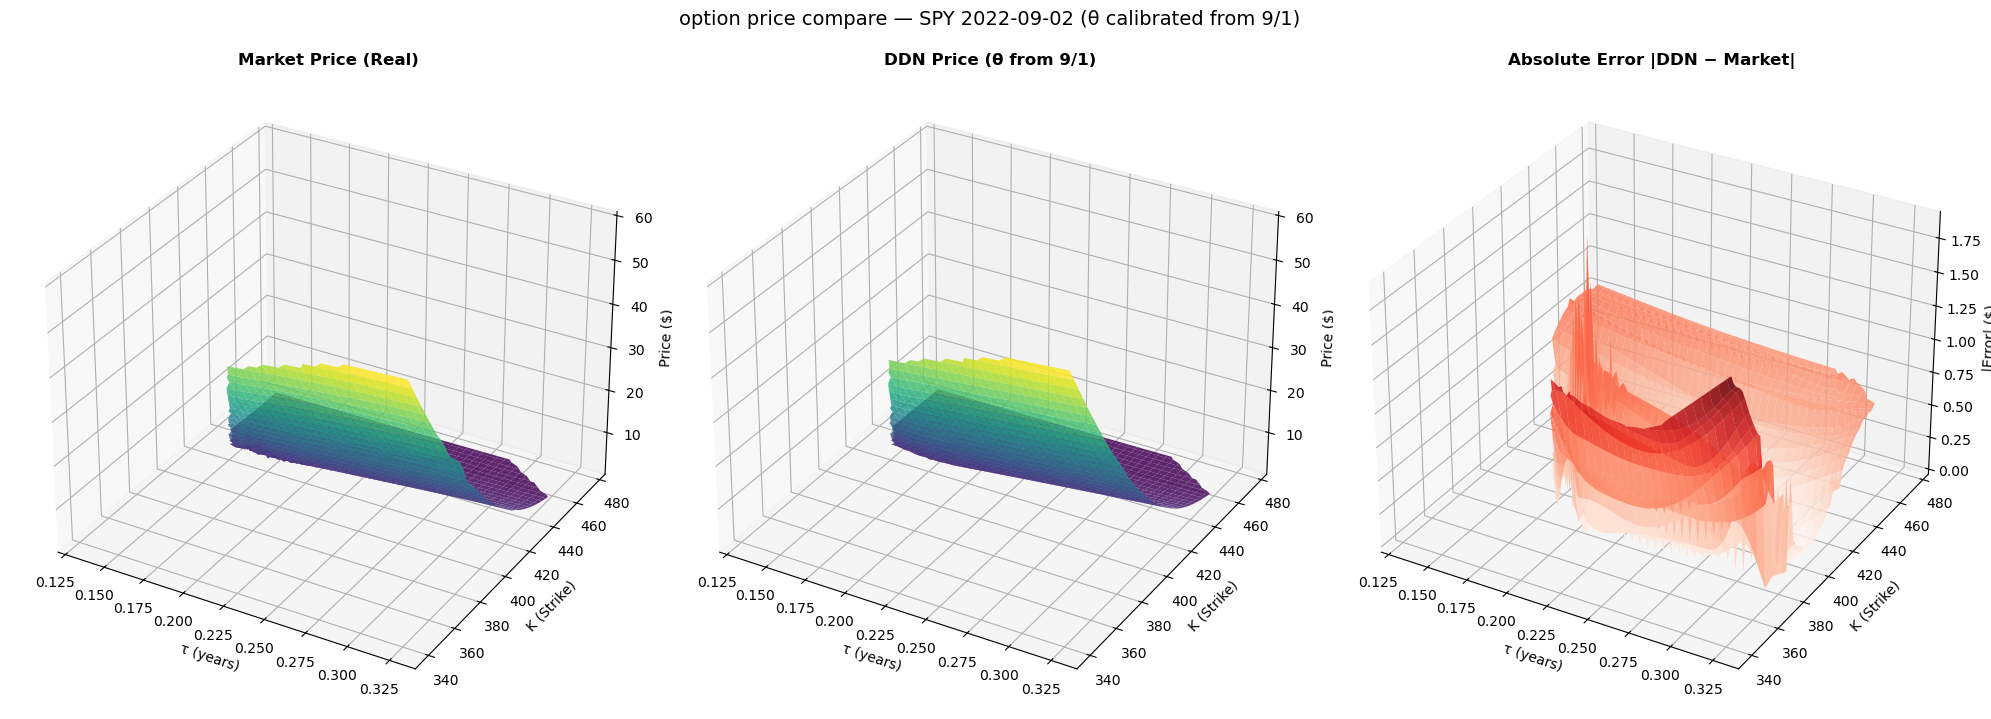

价格误差统计: 均值=$0.55, 最大=$1.90, 中位数=$0.55


In [3]:
## Cell 3: 曲面 1 — 期权价格光滑曲面 (τ × K → Price)

tau_vis = df_vis['tau'].values
K_vis   = df_vis['K'].values
P_mkt_vis = df_vis['P_mkt'].values

# ── 构建规则网格并插值 ──
tau_grid = np.linspace(tau_vis.min(), tau_vis.max(), 80)
K_grid   = np.linspace(K_vis.min(), K_vis.max(), 80)
TAU_G, K_G = np.meshgrid(tau_grid, K_grid)

# 用 cubic 插值将离散点 → 光滑曲面
P_mkt_surf = griddata((tau_vis, K_vis), P_mkt_vis, (TAU_G, K_G), method='cubic')
P_ddn_surf = griddata((tau_vis, K_vis), P_ddn_vis, (TAU_G, K_G), method='cubic')

# 误差曲面
P_err_surf = np.abs(P_ddn_surf - P_mkt_surf)

fig = plt.figure(figsize=(20, 7))

# ── 子图 1: 真实市场价格 ──
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(TAU_G, K_G, P_mkt_surf, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('K (Strike)', fontsize=10)
ax1.set_zlabel('Price ($)', fontsize=10)
ax1.set_title('Market Price (Real)', fontsize=12, fontweight='bold')

# ── 子图 2: DDN 定价 ──
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(TAU_G, K_G, P_ddn_surf, cmap='viridis', alpha=0.85, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('K (Strike)', fontsize=10)
ax2.set_zlabel('Price ($)', fontsize=10)
ax2.set_title('DDN Price (θ from 9/1)', fontsize=12, fontweight='bold')

# ── 子图 3: 绝对误差 ──
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(TAU_G, K_G, P_err_surf, cmap='Reds', alpha=0.85, edgecolor='none')
ax3.set_xlabel('τ (years)', fontsize=10)
ax3.set_ylabel('K (Strike)', fontsize=10)
ax3.set_zlabel('|Error| ($)', fontsize=10)
ax3.set_title('Absolute Error |DDN − Market|', fontsize=12, fontweight='bold')

# 统一 Z 轴范围 (子图1 & 2)
z_lo = min(np.nanmin(P_mkt_surf), np.nanmin(P_ddn_surf))
z_hi = max(np.nanmax(P_mkt_surf), np.nanmax(P_ddn_surf))
ax1.set_zlim(z_lo, z_hi)
ax2.set_zlim(z_lo, z_hi)

plt.suptitle('option price compare — SPY 2022-09-02 (θ calibrated from 9/1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

price_err = np.abs(P_ddn_vis - P_mkt_vis)
print(f'价格误差统计: 均值=${price_err.mean():.2f}, 最大=${price_err.max():.2f}, '
      f'中位数=${np.median(price_err):.2f}')

In [4]:
## Cell 4: 计算隐含波动率 (QuantLib Black-Scholes 反推)

def calc_implied_vol(price, S0, K, r, tau):
    """用 QuantLib BS 从期权价格反推隐含波动率。失败返回 np.nan。"""
    if price <= 0 or S0 <= 0 or K <= 0 or tau <= 0:
        return np.nan
    try:
        today = ql.Date(1, 1, 2024)
        ql.Settings.instance().evaluationDate = today
        day_count = ql.Actual365Fixed()
        maturity = today + max(1, int(tau * 365))

        spot = ql.QuoteHandle(ql.SimpleQuote(float(S0)))
        rate = ql.YieldTermStructureHandle(ql.FlatForward(today, float(r), day_count))
        div  = ql.YieldTermStructureHandle(ql.FlatForward(today, 0.0, day_count))

        payoff   = ql.PlainVanillaPayoff(ql.Option.Call, float(K))
        exercise = ql.EuropeanExercise(maturity)
        option   = ql.VanillaOption(payoff, exercise)

        process = ql.BlackScholesMertonProcess(spot, div, rate,
                    ql.BlackVolTermStructureHandle(
                        ql.BlackConstantVol(today, ql.NullCalendar(), 0.2, day_count)))
        option.setPricingEngine(ql.AnalyticEuropeanEngine(process))
        return option.impliedVolatility(float(price), process, 1e-6, 1000, 0.001, 5.0)
    except Exception:
        return np.nan

print('正在计算市场价格的隐含波动率...')
iv_market = np.array([
    calc_implied_vol(row['P_mkt'], row['S0'], row['K'], row['r'], row['tau'])
    for _, row in df_vis.iterrows()
])

print('正在计算 DDN 定价的隐含波动率...')
iv_ddn = np.array([
    calc_implied_vol(P_ddn_vis[i], row['S0'], row['K'], row['r'], row['tau'])
    for i, (_, row) in enumerate(df_vis.iterrows())
])

valid_mkt = ~np.isnan(iv_market)
valid_ddn = ~np.isnan(iv_ddn)
valid     = valid_mkt & valid_ddn
print(f'✅ IV 计算完成: 市场有效 {valid_mkt.sum()}/{len(iv_market)}, '
      f'DDN 有效 {valid_ddn.sum()}/{len(iv_ddn)}, 共同有效 {valid.sum()}')

正在计算市场价格的隐含波动率...
正在计算 DDN 定价的隐含波动率...
✅ IV 计算完成: 市场有效 200/200, DDN 有效 200/200, 共同有效 200


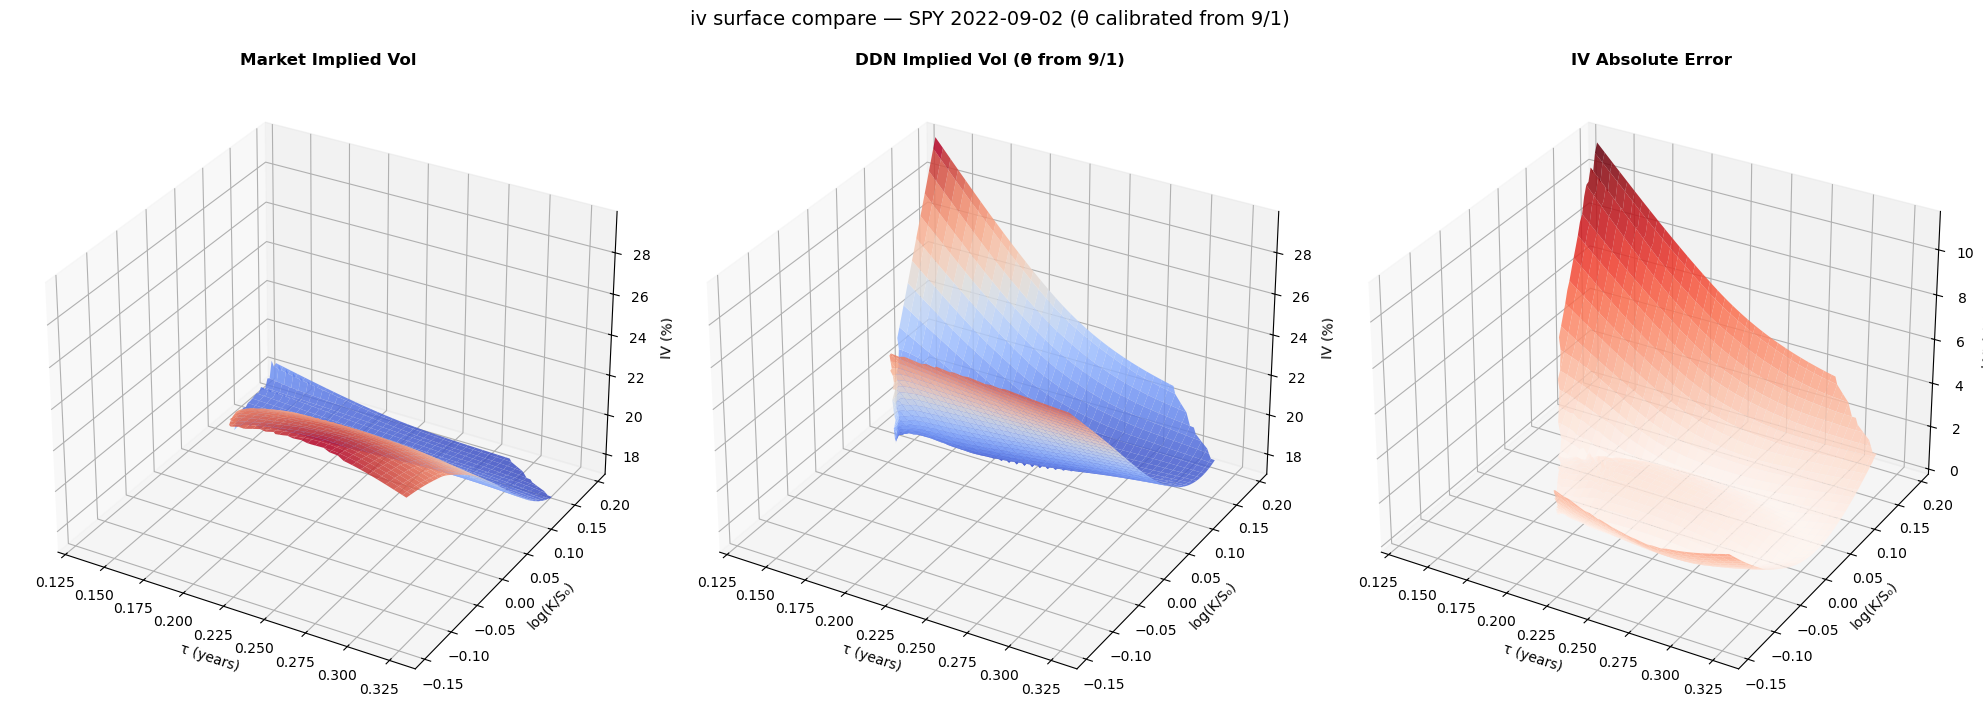

IV 误差统计: 均值=2.07%, 最大=11.44%, 中位数=1.01%


In [7]:
## Cell 5: 曲面 2 — 隐含波动率光滑曲面 (τ × log(K/S₀) → IV)

# 有效数据
tau_v  = df_vis['tau'].values[valid]
lks_v  = df_vis['log_K_S0'].values[valid]
iv_m_v = iv_market[valid] * 100   # 百分比
iv_d_v = iv_ddn[valid] * 100

# ── 构建规则网格并插值 ──
tau_grid2 = np.linspace(tau_v.min(), tau_v.max(), 80)
lks_grid  = np.linspace(lks_v.min(), lks_v.max(), 80)
TAU_G2, LKS_G = np.meshgrid(tau_grid2, lks_grid)

IV_mkt_surf = griddata((tau_v, lks_v), iv_m_v, (TAU_G2, LKS_G), method='cubic')
IV_ddn_surf = griddata((tau_v, lks_v), iv_d_v, (TAU_G2, LKS_G), method='cubic')
IV_err_surf = np.abs(IV_ddn_surf - IV_mkt_surf)

fig = plt.figure(figsize=(20, 7))

# ── 子图 1: 市场 IV 曲面 ──
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(TAU_G2, LKS_G, IV_mkt_surf, cmap='coolwarm', alpha=0.85, edgecolor='none')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('log(K/S₀)', fontsize=10)
ax1.set_zlabel('IV (%)', fontsize=10)
ax1.set_title('Market Implied Vol', fontsize=12, fontweight='bold')

# ── 子图 2: DDN IV 曲面 ──
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(TAU_G2, LKS_G, IV_ddn_surf, cmap='coolwarm', alpha=0.85, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('log(K/S₀)', fontsize=10)
ax2.set_zlabel('IV (%)', fontsize=10)
ax2.set_title('DDN Implied Vol (θ from 9/1)', fontsize=12, fontweight='bold')

# ── 子图 3: IV 误差 ──
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(TAU_G2, LKS_G, IV_err_surf, cmap='Reds', alpha=0.85, edgecolor='none')
ax3.set_xlabel('τ (years)', fontsize=10)
ax3.set_ylabel('log(K/S₀)', fontsize=10)
ax3.set_zlabel('|ΔIV| (%)', fontsize=10)
ax3.set_title('IV Absolute Error', fontsize=12, fontweight='bold')

# 统一 Z 轴范围 (子图1 & 2)
z_lo = min(np.nanmin(IV_mkt_surf), np.nanmin(IV_ddn_surf))
z_hi = max(np.nanmax(IV_mkt_surf), np.nanmax(IV_ddn_surf))
ax1.set_zlim(z_lo, z_hi)
ax2.set_zlim(z_lo, z_hi)

plt.suptitle('iv surface compare — SPY 2022-09-02 (θ calibrated from 9/1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

iv_err = np.abs(iv_d_v - iv_m_v)
print(f'IV 误差统计: 均值={iv_err.mean():.2f}%, 最大={iv_err.max():.2f}%, '
      f'中位数={np.median(iv_err):.2f}%')

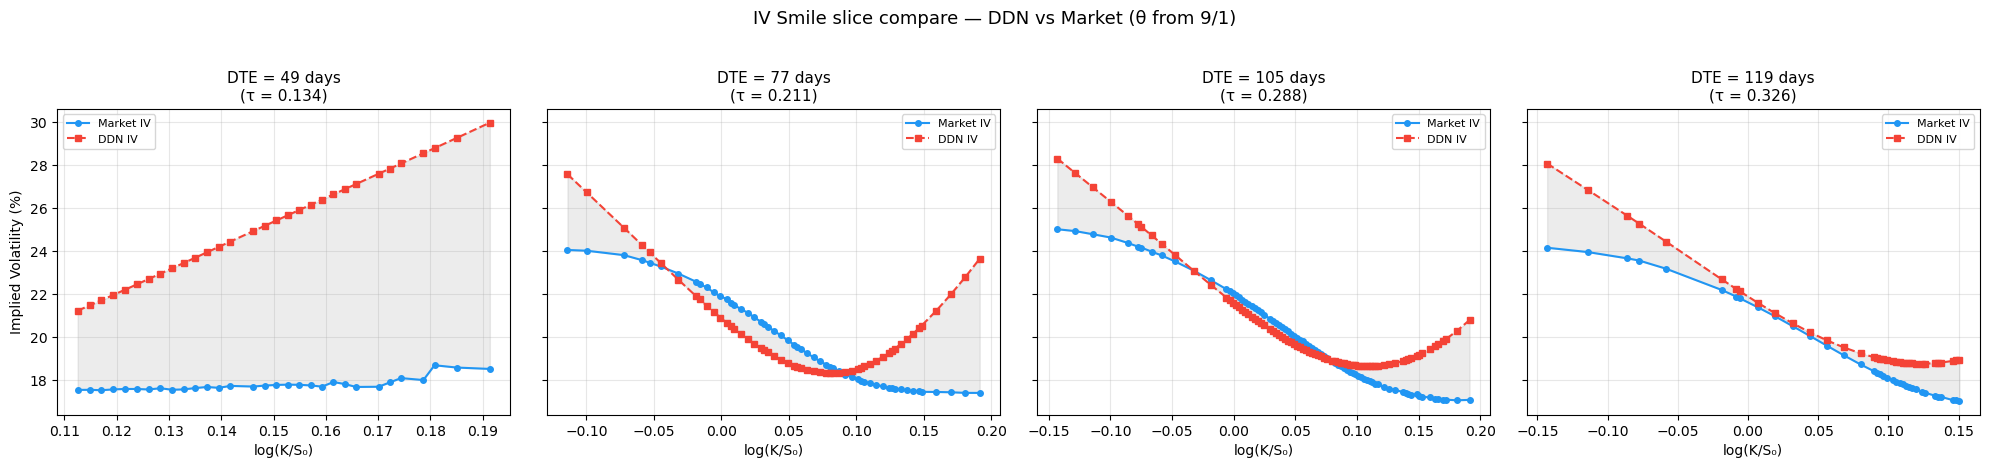

In [6]:
## Cell 6: 固定 τ 切片 — IV Smile 对比 (2D)

unique_tau = np.sort(df_vis['tau'].unique())
n_slices = min(4, len(unique_tau))
slice_idx = np.linspace(0, len(unique_tau) - 1, n_slices, dtype=int)
tau_slices = unique_tau[slice_idx]

fig, axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 4.5), sharey=True)
if n_slices == 1:
    axes = [axes]

for ax, tau_s in zip(axes, tau_slices):
    mask = (df_vis['tau'].values == tau_s) & valid
    if mask.sum() < 2:
        continue
    lks_slice = df_vis['log_K_S0'].values[mask]
    iv_m_slice = iv_market[mask] * 100
    iv_d_slice = iv_ddn[mask] * 100

    sort_idx = np.argsort(lks_slice)
    lks_s = lks_slice[sort_idx]
    iv_m_s = iv_m_slice[sort_idx]
    iv_d_s = iv_d_slice[sort_idx]

    ax.plot(lks_s, iv_m_s, 'o-', color='#2196F3', markersize=4, linewidth=1.5, label='Market IV')
    ax.plot(lks_s, iv_d_s, 's--', color='#F44336', markersize=4, linewidth=1.5, label='DDN IV')
    ax.fill_between(lks_s, iv_m_s, iv_d_s, alpha=0.15, color='gray')
    ax.set_xlabel('log(K/S₀)', fontsize=10)
    ax.set_title(f'DTE = {int(tau_s * 365)} days\n(τ = {tau_s:.3f})', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Implied Volatility (%)', fontsize=10)
plt.suptitle('IV Smile slice compare — DDN vs Market (θ from 9/1)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_56326/3975596166.py:24: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_56326/3975596166.py:24: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_56326/3975596166.py:24: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_56326/3975596166.py:24: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_56326/3975596166.py:24: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_r

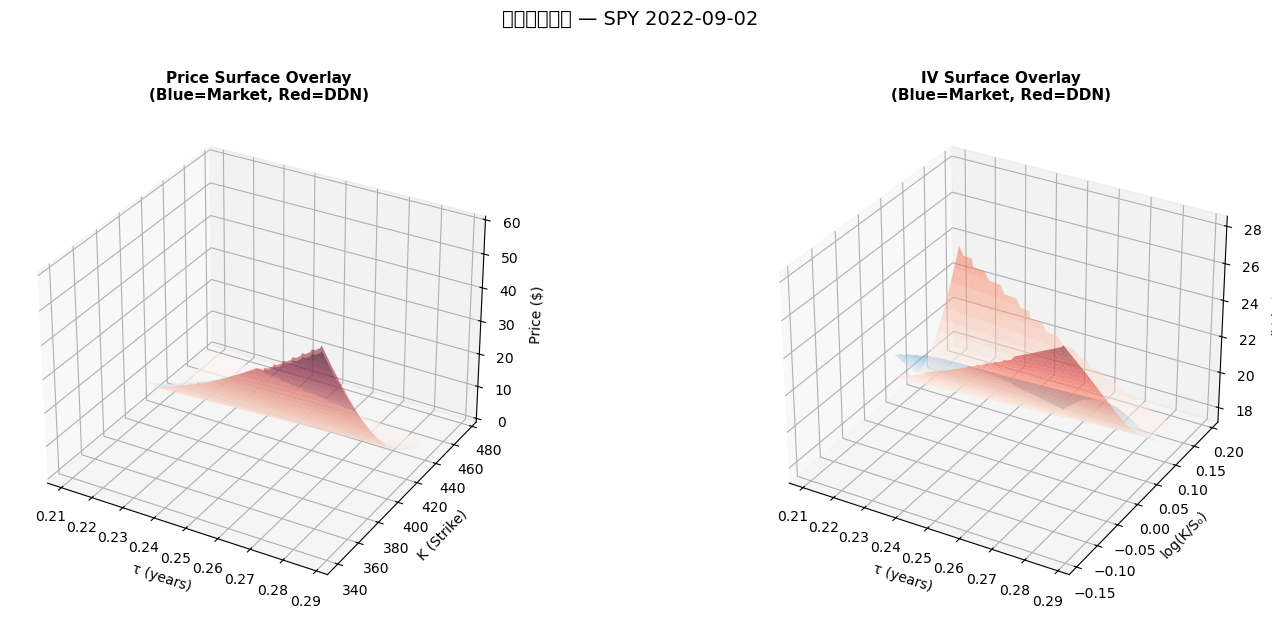

In [21]:
## Cell 7: 叠加曲面对比（Market vs DDN 在同一张图上）

fig = plt.figure(figsize=(16, 6))

# ── 左图: 价格曲面叠加 ──
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(TAU_G, K_G, P_mkt_surf, cmap='Blues', alpha=0.5, edgecolor='none', label='Market')
ax1.plot_surface(TAU_G, K_G, P_ddn_surf, cmap='Reds',  alpha=0.5, edgecolor='none', label='DDN')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('K (Strike)', fontsize=10)
ax1.set_zlabel('Price ($)', fontsize=10)
ax1.set_title('Price Surface Overlay\n(Blue=Market, Red=DDN)', fontsize=11, fontweight='bold')

# ── 右图: IV 曲面叠加 ──
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(TAU_G2, LKS_G, IV_mkt_surf, cmap='Blues', alpha=0.5, edgecolor='none')
ax2.plot_surface(TAU_G2, LKS_G, IV_ddn_surf, cmap='Reds',  alpha=0.5, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('log(K/S₀)', fontsize=10)
ax2.set_zlabel('IV (%)', fontsize=10)
ax2.set_title('IV Surface Overlay\n(Blue=Market, Red=DDN)', fontsize=11, fontweight='bold')

plt.suptitle('曲面叠加对比 — SPY 2022-09-02', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()